# 07 — Elastic Net Regression

## Objective

This notebook develops an Elastic Net Regression model for used-car price prediction.

The same train-test split, feature engineering, preprocessing pipeline, and log-transformed target will be retained for fair comparison.

The main objectives are to:

- combine L1 and L2 regularization,
- select the best `alpha` and `l1_ratio` using training-only cross-validation,
- evaluate performance using MAE, RMSE, and R²,
- compare Elastic Net with Linear, Ridge, and Lasso Regression,
- analyze coefficient shrinkage, sparsity, and stability,
- examine prediction and residual diagnostics.

## 1. Import Required Libraries



In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Validate the Dataset



In [2]:
data_path = "../data/raw/car_price_data.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Duplicate records:", df.duplicated().sum())
print("Missing Price values:", df["Price"].isna().sum())
print("Non-positive Price values:", (df["Price"] <= 0).sum())

df.head()

Dataset shape: (2059, 20)
Duplicate records: 0
Missing Price values: 0
Non-positive Price values: 0


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


### Initial Validation Observations

- The dataset contains 2,059 observations and 20 original columns.
- No duplicate records were found.
- The target variable, `Price`, contains no missing values.
- No zero or negative Price values were identified.
- The dataset is suitable for train-test splitting and log transformation.

## 3. Create the Train-Test Split

The predictor variables and target variable will be separated before preprocessing.

The dataset will be divided into 80% training data and 20% test data using `random_state=42`. The same split used for Linear, Ridge, and Lasso Regression is retained for a fair model comparison.

Feature engineering and preprocessing will be fitted using training data only to prevent data leakage.

In [3]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1647, 19)
X_test shape: (412, 19)
y_train shape: (1647,)
y_test shape: (412,)


### Train-Test Split Observations

- The training set contains 1,647 observations.
- The test set contains 412 observations.
- Each observation has 19 original predictor columns before feature engineering.
- The split exactly matches the Linear, Ridge, and Lasso notebooks.
- The test set remains reserved for final evaluation.

## 4. Apply Log Transformation to the Target

The `Price` target is strongly right-skewed. Therefore, `log1p` transformation will be applied separately to the training and test targets.

Elastic Net will be trained using the log-transformed training target. Predictions will later be converted back to the original Price scale using `expm1` before calculating MAE, RMSE, and R².

The same transformation is retained because it previously reduced training-target skewness and improved regression performance.

In [4]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original training Price skewness:", round(y_train.skew(), 2))
print("Log-transformed training Price skewness:", round(y_train_log.skew(), 2))

Original training Price skewness: 4.45
Log-transformed training Price skewness: 0.46


### Target Transformation Observations

- The original training Price distribution has strong positive skewness of 4.45.
- Log transformation reduces the skewness to 0.46.
- The transformed target is substantially more balanced and suitable for Elastic Net Regression.
- The same target transformation used in the previous models is retained for fair comparison.

## 5. Perform Feature Engineering

The same feature-engineering approach used in the previous notebooks will be retained for consistency.

The following numerical features will be created:

- `Vehicle_Age` from `Year`,
- `Engine_CC` from `Engine`,
- `Power_BHP` and `Power_RPM` from `Max Power`,
- `Torque_NM` and `Torque_RPM_Clean` from `Max Torque`.

Torque values reported in `kgm` will be converted to Newton-metres. After extraction, the original text-based technical columns will be removed.

Feature engineering will be applied separately to the training and test data after the split.

In [5]:
def extract_number(column):
    return pd.to_numeric(
        column.astype("string").str.extract(r"(\d+\.?\d*)")[0],
        errors="coerce"
    )


def extract_rpm(column):
    cleaned_column = column.astype("string").str.replace(",", "", regex=False)

    return pd.to_numeric(
        cleaned_column.str.extract(r"(?:@|at)\s*(\d+\.?\d*)")[0],
        errors="coerce"
    )


def engineer_features(data):
    data = data.copy()

    data["Vehicle_Age"] = 2022 - data["Year"]
    data["Engine_CC"] = extract_number(data["Engine"])
    data["Power_BHP"] = extract_number(data["Max Power"])
    data["Power_RPM"] = extract_rpm(data["Max Power"])
    data["Torque_NM"] = extract_number(data["Max Torque"])
    data["Torque_RPM_Clean"] = extract_rpm(data["Max Torque"])

    kgm_rows = data["Max Torque"].astype("string").str.contains(
        "kgm", case=False, na=False
    )
    data.loc[kgm_rows, "Torque_NM"] *= 9.80665

    data = data.drop(
        columns=["Year", "Engine", "Max Power", "Max Torque"]
    )

    return data


X_train_fe = engineer_features(X_train)
X_test_fe = engineer_features(X_test)

print("Training shape after feature engineering:", X_train_fe.shape)
print("Test shape after feature engineering:", X_test_fe.shape)

Training shape after feature engineering: (1647, 21)
Test shape after feature engineering: (412, 21)


### Feature Engineering Observations

- The training and test sets each contain 21 features after feature engineering.
- Useful numerical information was extracted from the original technical text columns.
- Torque values reported in `kgm` were converted to Newton-metres.
- Feature engineering was performed after the train-test split.
- The resulting shapes match the previous model notebooks.

## 6. Build the Preprocessing Pipeline

Numerical and categorical features will be identified from the feature-engineered training data.

The preprocessing pipeline will:

- impute numerical missing values using the training median,
- add numerical missing-value indicators,
- standardize numerical features,
- replace missing categorical values with `Missing`,
- group categories occurring fewer than five times,
- one-hot encode categorical features,
- ignore unseen categories in the test set,
- drop the first categorical level to reduce redundant dummy variables.

Preprocessing will remain inside the Elastic Net pipeline so that transformations are fitted only on training data during model fitting and cross-validation.

In [6]:
numerical_features = X_train_fe.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train_fe.select_dtypes(
    exclude=np.number
).columns.tolist()

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        min_frequency=5
    ))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total input features:", len(numerical_features) + len(categorical_features))

Numerical features: 12
Categorical features: 9
Total input features: 21


### Preprocessing Pipeline Observations

- The feature-engineered data contains 12 numerical and 9 categorical input features.
- Numerical features will be imputed, provided with missing indicators, and standardized.
- Categorical features will be imputed, grouped by frequency, and one-hot encoded.
- The first category will be dropped to reduce redundant dummy variables.
- The complete preprocessing workflow will be fitted inside the Elastic Net pipeline.

## 7. Train a Basic Elastic Net Regression Model

Elastic Net combines the L1 penalty used by Lasso with the L2 penalty used by Ridge.

Its two main hyperparameters are:

- `alpha`: controls the overall strength of regularization,
- `l1_ratio`: controls the balance between L1 and L2 penalties.

An `l1_ratio` closer to 1 gives more Lasso-like behavior, while a value closer to 0 gives more Ridge-like behavior.

A basic model with the default `alpha=1.0` and `l1_ratio=0.5` will first be trained as an initial reference. The best combination will later be selected using training-only cross-validation.

In [7]:
basic_elastic_net_model = Pipeline([
    ("preprocessor", preprocessor),
    ("elastic_net", ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=50000
    ))
])

basic_elastic_net_model.fit(
    X_train_fe,
    y_train_log
)

print("Basic Elastic Net model fitted successfully.")

Basic Elastic Net model fitted successfully.


### 7.1 Generate Basic Elastic Net Predictions

The fitted basic Elastic Net model will predict the test observations on the log-transformed target scale.

The log predictions will then be converted back to the original Price scale using `expm1`. Prediction count, negative values, and initial predicted prices will be checked before evaluation.

In [8]:
basic_elastic_net_log_predictions = basic_elastic_net_model.predict(
    X_test_fe
)

basic_elastic_net_price_predictions = np.expm1(
    basic_elastic_net_log_predictions
)

print("Predictions generated:", len(basic_elastic_net_price_predictions))
print(
    "Negative predictions:",
    (basic_elastic_net_price_predictions < 0).sum()
)
print(
    "First five predicted prices:",
    basic_elastic_net_price_predictions[:5].round(2)
)

Predictions generated: 412
Negative predictions: 0
First five predicted prices: [1624949.24  896827.34  856378.96  940256.82  831418.66]


C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Basic Elastic Net Prediction Observations

- Predictions were generated for all 412 test observations.
- The basic model produced no negative Price predictions.
- Predicted values vary across cars, unlike the all-zero basic Lasso solution.
- The first predictions appear compressed toward the central Price range, suggesting that `alpha=1.0` may still apply excessive regularization.
- The warning reports test categories that were not present during training.
- Because `handle_unknown="ignore"` was used, unseen categories were safely encoded as all zeros. The warning is informative and not an execution error.
- Final underfitting must be confirmed using evaluation metrics.

### 7.2 Evaluate the Basic Elastic Net Model

The basic Elastic Net predictions will be evaluated on the original Price scale using MAE, RMSE, and R².

Lower MAE and RMSE values are better, while higher R² indicates stronger predictive performance. These metrics will show whether the default `alpha=1.0` and `l1_ratio=0.5` combination causes underfitting.

In [9]:
basic_elastic_net_mae = mean_absolute_error(
    y_test,
    basic_elastic_net_price_predictions
)

basic_elastic_net_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        basic_elastic_net_price_predictions
    )
)

basic_elastic_net_r2 = r2_score(
    y_test,
    basic_elastic_net_price_predictions
)

print("Basic Elastic Net Regression Results")
print("Alpha: 1.0")
print("L1 ratio: 0.5")
print("MAE:", round(basic_elastic_net_mae, 2))
print("RMSE:", round(basic_elastic_net_rmse, 2))
print("R²:", round(basic_elastic_net_r2, 4))

Basic Elastic Net Regression Results
Alpha: 1.0
L1 ratio: 0.5
MAE: 1068826.38
RMSE: 2530338.69
R²: 0.0835


### Basic Elastic Net Evaluation Observations

- The basic Elastic Net model achieved an MAE of approximately 1,068,826.
- Its RMSE is approximately 2,530,339.
- The R² value of 0.0835 indicates that the model captures only a small amount of test-set Price variation.
- The model performs better than the all-zero basic Lasso solution but remains severely underfitted.
- The default `alpha=1.0` applies excessive overall regularization for this dataset.
- Both `alpha` and `l1_ratio` must be selected using training-only cross-validation.

## 8. Select the Best Alpha and L1 Ratio Using Cross-Validation

Elastic Net requires joint tuning of `alpha` and `l1_ratio`.

A range of weak to strong alpha values will be combined with different L1/L2 penalty mixtures. Five-fold cross-validation will evaluate every combination using training data only.

The combination with the lowest mean validation RMSE on the log-transformed target will be selected. The complete preprocessing pipeline will be refitted inside every fold to prevent data leakage.

The test set will remain completely unused during hyperparameter selection.

In [10]:
alpha_values = [
    0.00001, 0.00005, 0.0001, 0.0002,
    0.0005, 0.001, 0.002, 0.005,
    0.01, 0.05, 0.1
]

l1_ratio_values = [
    0.05, 0.10, 0.25, 0.50,
    0.75, 0.90, 0.95
]

elastic_net_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("elastic_net", ElasticNet(max_iter=50000))
])

cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

elastic_net_search = GridSearchCV(
    estimator=elastic_net_cv_pipeline,
    param_grid={
        "elastic_net__alpha": alpha_values,
        "elastic_net__l1_ratio": l1_ratio_values
    },
    scoring="neg_root_mean_squared_error",
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True
)

elastic_net_search.fit(
    X_train_fe,
    y_train_log
)

best_elastic_net_alpha = elastic_net_search.best_params_[
    "elastic_net__alpha"
]

best_elastic_net_l1_ratio = elastic_net_search.best_params_[
    "elastic_net__l1_ratio"
]

best_elastic_net_cv_rmse = -elastic_net_search.best_score_

print("Parameter combinations tested:", len(alpha_values) * len(l1_ratio_values))
print("Best alpha:", best_elastic_net_alpha)
print("Best L1 ratio:", best_elastic_net_l1_ratio)
print(
    "Best mean validation Log RMSE:",
    round(best_elastic_net_cv_rmse, 4)
)

Parameter combinations tested: 77
Best alpha: 0.0002
Best L1 ratio: 0.95
Best mean validation Log RMSE: 0.2713


### Initial Hyperparameter Search Observations

- The initial search evaluated 77 alpha and L1-ratio combinations.
- It selected `alpha=0.0002` and `l1_ratio=0.95`.
- The best mean validation Log RMSE is 0.2713.
- The result is slightly better than the previous Lasso validation Log RMSE of 0.2718.
- The selected L1 ratio indicates that the best Elastic Net solution is strongly Lasso-like, with a small L2 contribution.
- Because `l1_ratio=0.95` is the upper boundary of the initial grid, the region between 0.95 and 1.00 should be refined before final model selection.

### 8.1 Refine the Best Hyperparameter Region

A focused second search will test alpha values around 0.0002 and L1 ratios between 0.90 and 1.00.

The same five training folds, preprocessing pipeline, and Log RMSE scoring will be retained. Including `l1_ratio=1.0` will determine whether a true Elastic Net mixture performs better than the pure Lasso endpoint.

In [11]:
refined_alpha_values = [
    0.00010, 0.00015, 0.00020,
    0.00025, 0.00030, 0.00040
]

refined_l1_ratio_values = [
    0.900, 0.925, 0.950,
    0.975, 0.990, 1.000
]

refined_elastic_net_search = GridSearchCV(
    estimator=elastic_net_cv_pipeline,
    param_grid={
        "elastic_net__alpha": refined_alpha_values,
        "elastic_net__l1_ratio": refined_l1_ratio_values
    },
    scoring="neg_root_mean_squared_error",
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True
)

refined_elastic_net_search.fit(
    X_train_fe,
    y_train_log
)

best_elastic_net_alpha = refined_elastic_net_search.best_params_[
    "elastic_net__alpha"
]

best_elastic_net_l1_ratio = refined_elastic_net_search.best_params_[
    "elastic_net__l1_ratio"
]

best_elastic_net_cv_rmse = -refined_elastic_net_search.best_score_

print(
    "Refined combinations tested:",
    len(refined_alpha_values) * len(refined_l1_ratio_values)
)
print("Final best alpha:", best_elastic_net_alpha)
print("Final best L1 ratio:", best_elastic_net_l1_ratio)
print(
    "Final best mean validation Log RMSE:",
    round(best_elastic_net_cv_rmse, 4)
)

Refined combinations tested: 36
Final best alpha: 0.0002
Final best L1 ratio: 1.0
Final best mean validation Log RMSE: 0.2712


### Refined Search Observations

- The refined search evaluated 36 focused hyperparameter combinations.
- The overall best result uses `alpha=0.0002` and `l1_ratio=1.0`.
- Its mean validation Log RMSE is 0.2712.
- An `l1_ratio` of 1.0 removes the L2 component and makes the estimator mathematically equivalent to Lasso.
- Therefore, the overall search result indicates that pure L1 regularization is preferred by the validation metric.
- This endpoint should not be reported as a genuine mixed Elastic Net model.
- The best combination with `l1_ratio < 1.0` will be identified separately for a valid Elastic Net comparison.

### 8.2 Select the Best True Elastic Net Mixture

The refined cross-validation results will be converted into a table.

Combinations with `l1_ratio=1.0` will be excluded when selecting the final Elastic Net mixture because they represent pure Lasso. The remaining combination with the lowest mean validation Log RMSE will be used as the final Elastic Net model.

The pure-Lasso endpoint will remain in the results for transparent comparison.

In [12]:
overall_best_alpha = best_elastic_net_alpha
overall_best_l1_ratio = best_elastic_net_l1_ratio
overall_best_cv_rmse = best_elastic_net_cv_rmse

refined_elastic_net_cv_results = pd.DataFrame({
    "Alpha": refined_elastic_net_search.cv_results_[
        "param_elastic_net__alpha"
    ],
    "L1 Ratio": refined_elastic_net_search.cv_results_[
        "param_elastic_net__l1_ratio"
    ],
    "Mean Train Log RMSE": -refined_elastic_net_search.cv_results_[
        "mean_train_score"
    ],
    "Mean Validation Log RMSE": -refined_elastic_net_search.cv_results_[
        "mean_test_score"
    ],
    "Validation RMSE Standard Deviation": refined_elastic_net_search.cv_results_[
        "std_test_score"
    ],
    "Rank": refined_elastic_net_search.cv_results_[
        "rank_test_score"
    ]
})

refined_elastic_net_cv_results["Alpha"] = pd.to_numeric(
    refined_elastic_net_cv_results["Alpha"]
)

refined_elastic_net_cv_results["L1 Ratio"] = pd.to_numeric(
    refined_elastic_net_cv_results["L1 Ratio"]
)

true_elastic_net_results = refined_elastic_net_cv_results[
    refined_elastic_net_cv_results["L1 Ratio"] < 1.0
].sort_values(
    "Mean Validation Log RMSE"
).reset_index(drop=True)

best_true_elastic_net = true_elastic_net_results.iloc[0]

best_elastic_net_alpha = best_true_elastic_net["Alpha"]
best_elastic_net_l1_ratio = best_true_elastic_net["L1 Ratio"]
best_elastic_net_cv_rmse = best_true_elastic_net[
    "Mean Validation Log RMSE"
]

print("Best true Elastic Net alpha:", best_elastic_net_alpha)
print("Best true Elastic Net L1 ratio:", best_elastic_net_l1_ratio)
print(
    "Best true Elastic Net validation Log RMSE:",
    round(best_elastic_net_cv_rmse, 6)
)
print(
    "Difference from pure-Lasso endpoint:",
    round(best_elastic_net_cv_rmse - overall_best_cv_rmse, 6)
)

refined_elastic_net_cv_results.sort_values(
    "Mean Validation Log RMSE"
).head(12).round(6)

Best true Elastic Net alpha: 0.0002
Best true Elastic Net L1 ratio: 0.99
Best true Elastic Net validation Log RMSE: 0.271242
Difference from pure-Lasso endpoint: 1.2e-05


,Alpha,L1 Ratio,Mean Train Log RMSE,Mean Validation Log RMSE,Validation RMSE Standard Deviation,Rank
17,0.00020,1.000,0.226777,0.271231,0.026342,1
16,0.00020,0.990,0.226755,0.271242,0.026344,2
15,0.00020,0.975,0.226722,0.271260,0.026346,3
14,0.00020,0.950,0.226668,0.271291,0.026351,4
13,0.00020,0.925,0.226615,0.271322,0.026356,5
12,0.00020,0.900,0.226562,0.271358,0.026358,6
20,0.00025,0.950,0.227475,0.271382,0.026184,7
21,0.00025,0.975,0.227552,0.271387,0.026160,8
19,0.00025,0.925,0.227398,0.271387,0.026202,9
22,0.00025,0.990,0.227599,0.271394,0.026143,10


### Best True Elastic Net Selection Observations

- The best genuine Elastic Net mixture uses `alpha=0.0002` and `l1_ratio=0.99`.
- Its mean validation Log RMSE is 0.271242.
- The pure-Lasso endpoint achieves 0.271231.
- The difference is only 0.000012, which is negligible relative to the validation standard deviation of approximately 0.0263.
- The selected mixture contains approximately 99% L1 influence and 1% L2 influence.
- Validation performance therefore strongly favors Lasso-like behavior, while a very small L2 component produces almost identical accuracy.
- The best true mixture will be retained for Elastic Net evaluation so that its model label remains technically correct.

### 8.3 Visualize Cross-Validation Performance

The initial cross-validation results will be displayed as a heatmap.

Rows will represent alpha values, columns will represent L1 ratios, and each cell will show the mean validation Log RMSE. Lower values indicate better validation performance.

This visualization will show how the overall regularization strength and the L1/L2 balance interact.

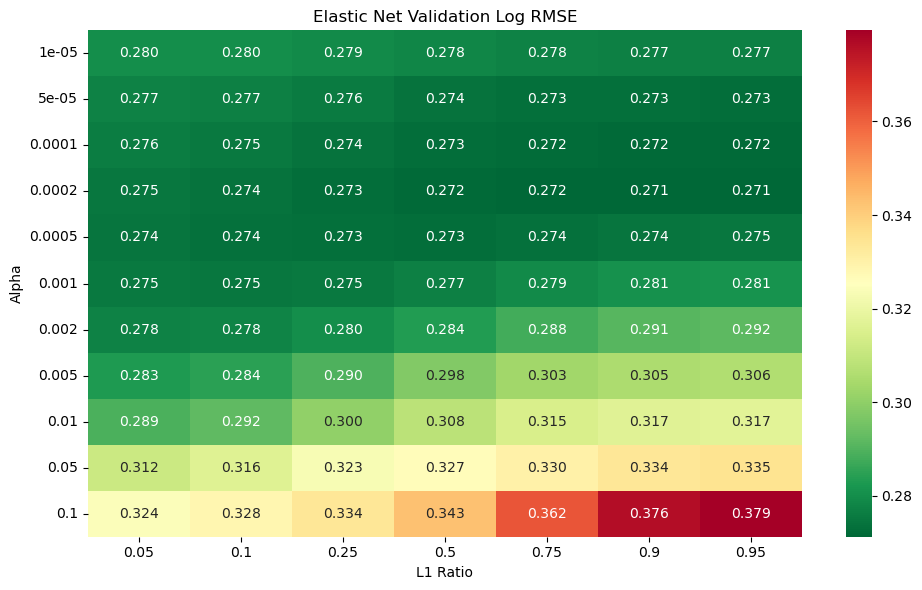

In [15]:
initial_elastic_net_cv_results = pd.DataFrame({
    "Alpha": elastic_net_search.cv_results_["param_elastic_net__alpha"],
    "L1 Ratio": elastic_net_search.cv_results_["param_elastic_net__l1_ratio"],
    "Mean Validation Log RMSE": -elastic_net_search.cv_results_["mean_test_score"]
})

initial_elastic_net_cv_results["Alpha"] = pd.to_numeric(
    initial_elastic_net_cv_results["Alpha"]
)

initial_elastic_net_cv_results["L1 Ratio"] = pd.to_numeric(
    initial_elastic_net_cv_results["L1 Ratio"]
)

heatmap_data = initial_elastic_net_cv_results.pivot(
    index="Alpha",
    columns="L1 Ratio",
    values="Mean Validation Log RMSE"
)

figure_directory = Path("../results/figures")
figure_directory.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r"
)

plt.title("Elastic Net Validation Log RMSE")
plt.xlabel("L1 Ratio")
plt.ylabel("Alpha")
plt.tight_layout()

plt.savefig(
    figure_directory / "elastic_net_cv_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The lowest validation Log RMSE appears around `alpha = 0.0002` with high L1 ratios. This confirms that the model performs best with weak overall regularization and a strongly Lasso-dominant penalty.

Validation error increases when alpha becomes larger, particularly at high L1 ratios. This indicates excessive coefficient shrinkage and underfitting.

The heatmap supports the refined search result, where a true Elastic Net combination of `alpha = 0.0002` and `l1_ratio = 0.99` was selected.

## 9. Fit the Best True Elastic Net Model

A final true Elastic Net pipeline will be created using the selected hyperparameters:

- `alpha = 0.0002`
- `l1_ratio = 0.99`

The complete pipeline will be fitted on the full training data. The test data will remain untouched during model fitting.

In [16]:
best_elastic_net_model = Pipeline([
    ("preprocessor", preprocessor),
    ("elastic_net", ElasticNet(
        alpha=best_elastic_net_alpha,
        l1_ratio=best_elastic_net_l1_ratio,
        max_iter=50000
    ))
])

best_elastic_net_model.fit(X_train_fe, y_train_log)

print("Best true Elastic Net model fitted successfully.")
print("Selected alpha:", best_elastic_net_alpha)
print("Selected L1 ratio:", best_elastic_net_l1_ratio)

Best true Elastic Net model fitted successfully.
Selected alpha: 0.0002
Selected L1 ratio: 0.99


#### Observation

The best true Elastic Net model was fitted successfully using `alpha = 0.0002` and `l1_ratio = 0.99`.

These hyperparameters were selected using cross-validation on the training data only. Therefore, the test set remains independent for final model evaluation.

### 9.1 Generate Test-Set Predictions

The fitted Elastic Net model will predict the test observations on the log-transformed target scale.

The log predictions will then be converted back to the original Price scale using `expm1`. Final evaluation metrics will be calculated using the original car prices.

In [17]:
best_elastic_net_predictions_log = best_elastic_net_model.predict(
    X_test_fe
)

best_elastic_net_predictions = np.expm1(
    best_elastic_net_predictions_log
)

print("Predictions generated:", len(best_elastic_net_predictions))
print(
    "Negative predictions:",
    np.sum(best_elastic_net_predictions < 0)
)
print(
    "First five predicted prices:",
    np.round(best_elastic_net_predictions[:5], 2)
)

Predictions generated: 412
Negative predictions: 0
First five predicted prices: [4340080.11  743471.83  577180.05 1156819.38  605457.15]


C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


#### Observation

The model generated predictions for all 412 test observations, and no negative prices were produced.

The warning indicates that some test observations contain categories that were not present during training. Because `handle_unknown="ignore"` was used, these unseen categories were encoded as all zeros without stopping prediction.

This is expected behavior and prevents pipeline failure, although unseen categories provide limited information to the model.

### 9.2 Evaluate the Best True Elastic Net Model

The final Elastic Net predictions will be evaluated on the independent test set using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

All metrics will be calculated on the original Price scale for practical interpretation and fair comparison with the previous models.

In [18]:
best_elastic_net_mae = mean_absolute_error(
    y_test,
    best_elastic_net_predictions
)

best_elastic_net_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_elastic_net_predictions
    )
)

best_elastic_net_r2 = r2_score(
    y_test,
    best_elastic_net_predictions
)

print("Best True Elastic Net Regression Results")
print("Selected alpha:", best_elastic_net_alpha)
print("Selected L1 ratio:", best_elastic_net_l1_ratio)
print("MAE:", round(best_elastic_net_mae, 2))
print("RMSE:", round(best_elastic_net_rmse, 2))
print("R²:", round(best_elastic_net_r2, 4))

Best True Elastic Net Regression Results
Selected alpha: 0.0002
Selected L1 ratio: 0.99
MAE: 297853.55
RMSE: 998411.09
R²: 0.8573


#### Observation

The best true Elastic Net model achieved an MAE of approximately 297,854, an RMSE of approximately 998,411, and an R² of 0.8573.

The model explains about 85.73% of the variation in test-set car prices. It produced the lowest MAE among the models evaluated so far, indicating strong average prediction accuracy.

The RMSE remains much higher than the MAE, showing that a small number of expensive vehicles still produce large prediction errors. The selected `l1_ratio = 0.99` confirms that the model is strongly Lasso-dominant while retaining a small Ridge contribution.

## 10. Compare Elastic Net with Previous Regression Models

The Basic and Best True Elastic Net results will be added to the previous model comparison table.

All models used the same train-test split, log-target strategy, preprocessing approach, and evaluation metrics. Therefore, their test results can be compared fairly.

In [20]:
results_directory = Path("../results")

previous_model_comparison = pd.read_csv(
    results_directory / "lasso_model_comparison.csv"
)

previous_model_comparison["L1 Ratio"] = np.nan

basic_predictions_for_comparison = np.expm1(
    basic_elastic_net_model.predict(X_test_fe)
)

elastic_net_rows = pd.DataFrame({
    "Model": [
        "Basic Elastic Net Regression",
        "Best True Elastic Net Regression"
    ],
    "Alpha": [
        1.0,
        best_elastic_net_alpha
    ],
    "L1 Ratio": [
        0.5,
        best_elastic_net_l1_ratio
    ],
    "MAE": [
        basic_elastic_net_mae,
        best_elastic_net_mae
    ],
    "RMSE": [
        basic_elastic_net_rmse,
        best_elastic_net_rmse
    ],
    "R2": [
        basic_elastic_net_r2,
        best_elastic_net_r2
    ],
    "Negative Predictions": [
        np.sum(basic_predictions_for_comparison < 0),
        np.sum(best_elastic_net_predictions < 0)
    ]
})

elastic_net_model_comparison = pd.concat(
    [previous_model_comparison, elastic_net_rows],
    ignore_index=True
)

elastic_net_model_comparison = elastic_net_model_comparison[[
    "Model",
    "Alpha",
    "L1 Ratio",
    "MAE",
    "RMSE",
    "R2",
    "Negative Predictions"
]]

elastic_net_model_comparison.round(4)

C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,Alpha,L1 Ratio,MAE,RMSE,R2,Negative Predictions
0,Log-Target Linear Regression,NaN,NaN,3.023453e+05,9.967745e+05,0.8578,0
1,Basic Ridge Regression,1.0000,NaN,3.017403e+05,9.909551e+05,0.8594,0
2,Best Ridge Regression,0.5000,NaN,3.011827e+05,9.991986e+05,0.8571,0
3,Basic Lasso Regression,1.0000,NaN,1.244716e+06,2.743962e+06,-0.0777,0
4,Best Lasso Regression,0.0001,NaN,2.984359e+05,1.003504e+06,0.8559,0
5,Basic Elastic Net Regression,1.0000,0.50,1.068826e+06,2.530339e+06,0.0835,0
6,Best True Elastic Net Regression,0.0002,0.99,2.978535e+05,9.984111e+05,0.8573,0


#### Observation

Hyperparameter tuning improved Elastic Net substantially. MAE decreased from approximately 1,068,826 to 297,854, while R² increased from 0.0835 to 0.8573.

The Best True Elastic Net achieved the lowest MAE among all compared models. Basic Ridge retained the lowest RMSE and highest R², although the performance differences among the strongest models were small.

The Best True Elastic Net also outperformed the Best Lasso in all three evaluation metrics. This suggests that adding a small Ridge contribution improved predictive performance while retaining mostly Lasso-like behavior.

All compared log-target models produced zero negative price predictions.

## 11. Analyze Elastic Net Coefficients

Elastic Net combines L1 and L2 regularization. It can shrink coefficient magnitudes and set some coefficients exactly to zero.

The fitted feature names and coefficients will be extracted from the final pipeline. Features with zero coefficients will be treated as removed by Elastic Net.

Because the target is log-transformed, coefficients represent changes on the Log Price scale. Numerical features are standardized, while categorical coefficients are interpreted relative to their reference categories.

In [21]:
elastic_net_feature_names = (
    best_elastic_net_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

elastic_net_feature_names = pd.Series(
    elastic_net_feature_names
).str.replace(
    r"^[^_]+__",
    "",
    regex=True
)

elastic_net_coefficients = (
    best_elastic_net_model
    .named_steps["elastic_net"]
    .coef_
)

elastic_net_intercept = (
    best_elastic_net_model
    .named_steps["elastic_net"]
    .intercept_
)

elastic_net_coefficient_table = pd.DataFrame({
    "Feature": elastic_net_feature_names,
    "Elastic Net Coefficient": elastic_net_coefficients
})

elastic_net_coefficient_table["Absolute Elastic Net Coefficient"] = (
    elastic_net_coefficient_table["Elastic Net Coefficient"].abs()
)

elastic_net_coefficient_table["Selected"] = (
    elastic_net_coefficient_table["Elastic Net Coefficient"] != 0
)

elastic_net_coefficient_table = elastic_net_coefficient_table.sort_values(
    "Absolute Elastic Net Coefficient",
    ascending=False
).reset_index(drop=True)

selected_elastic_net_features = (
    elastic_net_coefficient_table["Selected"].sum()
)

zero_elastic_net_coefficients = (
    len(elastic_net_coefficient_table)
    - selected_elastic_net_features
)

print("Total coefficients:", len(elastic_net_coefficient_table))
print("Selected non-zero coefficients:", selected_elastic_net_features)
print("Exactly zero coefficients:", zero_elastic_net_coefficients)
print("Elastic Net intercept:", round(elastic_net_intercept, 4))

elastic_net_coefficient_table.head(15).round(4)

Total coefficients: 160
Selected non-zero coefficients: 124
Exactly zero coefficients: 36
Elastic Net intercept: 14.2923


,Feature,Elastic Net Coefficient,Absolute Elastic Net Coefficient,Selected
0,Make_Datsun,-0.8356,0.8356,True
1,Make_Chevrolet,-0.7158,0.7158,True
2,Make_Tata,-0.7013,0.7013,True
3,Make_Renault,-0.6876,0.6876,True
4,Make_Nissan,-0.6638,0.6638,True
5,Make_MG,-0.5704,0.5704,True
6,Owner_infrequent_sklearn,-0.5430,0.5430,True
7,Make_Mahindra,-0.5305,0.5305,True
8,Make_Volkswagen,-0.5216,0.5216,True
9,Make_Maruti Suzuki,-0.5185,0.5185,True


#### Observation

The final Elastic Net model retained 124 of the 160 processed features and set 36 coefficients exactly to zero. Therefore, it performed automatic feature selection while keeping most potentially useful information.

Elastic Net removed more features than the Best Lasso model, which removed 25 features. However, this comparison is also influenced by their different selected alpha values.

Several vehicle-make categories have the largest coefficient magnitudes. These coefficients represent conditional associations with Log Price relative to the omitted reference category; they should not be interpreted as causal effects.

### 11.1 Inspect Features Removed by Elastic Net

Features with coefficients exactly equal to zero will be listed.

These features were excluded from the final prediction equation under the selected regularization settings. However, a zero coefficient does not prove that a feature is universally irrelevant because selection can be affected by correlated features, sample size, and the chosen hyperparameters.

In [22]:
elastic_net_removed_features = (
    elastic_net_coefficient_table[
        elastic_net_coefficient_table["Selected"] == False
    ][
        ["Feature", "Elastic Net Coefficient"]
    ]
    .sort_values("Feature")
    .reset_index(drop=True)
)

print(
    "Features removed by Elastic Net:",
    len(elastic_net_removed_features)
)

elastic_net_removed_features

Features removed by Elastic Net: 36


,Feature,Elastic Net Coefficient
0,Color_Brown,0.0
1,Color_Green,0.0
2,Color_Maroon,-0.0
3,Color_Others,-0.0
4,Fuel Type_Electric,0.0
5,Location_Delhi,0.0
6,Location_Jalandhar,-0.0
7,Location_Lucknow,-0.0
8,Location_Meerut,0.0
9,Location_Noida,0.0


#### Observation

Most features removed by Elastic Net are one-hot encoded model, location, and color categories. Their information may be weak, rare, or represented by other correlated features.

Elastic Net also removed `Power_RPM`, which previously had a relatively high VIF. This suggests that the model preferred other correlated technical features under the selected combined penalty.

The values displayed as `-0.0` are computationally equal to zero and have the same interpretation as `0.0`. These selections are specific to this dataset and should not be treated as universal evidence of feature irrelevance.

## 12. Compare Linear, Ridge, Lasso, and Elastic Net Coefficients

The saved Linear, Ridge, and Lasso coefficient comparison will be combined with the final Elastic Net coefficients.

All coefficients correspond to the same 160 processed features. This allows feature-level comparison of coefficient magnitude, shrinkage, and selection across the four models.

In [23]:
previous_coefficient_comparison = pd.read_csv(
    results_directory / "linear_ridge_lasso_coefficients.csv"
)

previous_coefficient_comparison = (
    previous_coefficient_comparison.rename(
        columns={"Selected": "Lasso Selected"}
    )
)

elastic_net_for_comparison = elastic_net_coefficient_table[[
    "Feature",
    "Elastic Net Coefficient",
    "Absolute Elastic Net Coefficient",
    "Selected"
]].rename(
    columns={"Selected": "Elastic Net Selected"}
)

all_model_coefficient_comparison = (
    previous_coefficient_comparison.merge(
        elastic_net_for_comparison,
        on="Feature",
        how="inner",
        validate="one_to_one"
    )
)

print(
    "Linear, Ridge, and Lasso features:",
    len(previous_coefficient_comparison)
)
print(
    "Elastic Net features:",
    len(elastic_net_for_comparison)
)
print(
    "Matched features:",
    len(all_model_coefficient_comparison)
)

all_model_coefficient_comparison.head().round(4)

Linear, Ridge, and Lasso features: 160
Elastic Net features: 160
Matched features: 160


,Feature,Linear Coefficient,Ridge Coefficient,Absolute Linear Coefficient,Absolute Ridge Coefficient,Magnitude Change,Lasso Coefficient,Absolute Lasso Coefficient,Lasso Selected,Lasso Magnitude Change from Linear,Elastic Net Coefficient,Absolute Elastic Net Coefficient,Elastic Net Selected
0,Make_Datsun,-0.9942,-0.8260,0.9942,0.8260,0.1683,-0.9109,0.9109,True,0.0833,-0.8356,0.8356,True
1,Make_Chevrolet,-0.8855,-0.7220,0.8855,0.7220,0.1636,-0.7976,0.7976,True,0.0879,-0.7158,0.7158,True
2,Make_Nissan,-0.8089,-0.6775,0.8089,0.6775,0.1314,-0.7338,0.7338,True,0.0751,-0.6638,0.6638,True
3,Make_MG,-0.7049,-0.5795,0.7049,0.5795,0.1254,-0.6351,0.6351,True,0.0698,-0.5704,0.5704,True
4,Make_Renault,-0.8010,-0.6851,0.8010,0.6851,0.1159,-0.7389,0.7389,True,0.0621,-0.6876,0.6876,True


#### Observation

All 160 processed features were matched successfully across Linear, Ridge, Lasso, and Elastic Net. Therefore, the coefficient comparison is complete and valid.

For the displayed high-magnitude brand features, all regularized models reduced coefficient magnitudes compared with Linear Regression.

Elastic Net coefficients are generally smaller than the corresponding Lasso coefficients and close to Ridge coefficients in these examples. This reflects the stronger selected alpha and the combined L1/L2 penalty.

### 12.1 Quantify Elastic Net Coefficient Shrinkage

Coefficient shrinkage will be measured using L1 and L2 norms.

- The L1 norm is the sum of absolute coefficient magnitudes.
- The L2 norm measures the overall Euclidean magnitude of the coefficient vector.

Smaller norms indicate stronger overall shrinkage. Feature-level magnitude changes will also be calculated relative to Linear Regression.

In [24]:
linear_l1_norm = (
    all_model_coefficient_comparison["Linear Coefficient"]
    .abs()
    .sum()
)

ridge_l1_norm = (
    all_model_coefficient_comparison["Ridge Coefficient"]
    .abs()
    .sum()
)

lasso_l1_norm = (
    all_model_coefficient_comparison["Lasso Coefficient"]
    .abs()
    .sum()
)

elastic_net_l1_norm = (
    all_model_coefficient_comparison["Elastic Net Coefficient"]
    .abs()
    .sum()
)

linear_l2_norm = np.linalg.norm(
    all_model_coefficient_comparison["Linear Coefficient"]
)

ridge_l2_norm = np.linalg.norm(
    all_model_coefficient_comparison["Ridge Coefficient"]
)

lasso_l2_norm = np.linalg.norm(
    all_model_coefficient_comparison["Lasso Coefficient"]
)

elastic_net_l2_norm = np.linalg.norm(
    all_model_coefficient_comparison["Elastic Net Coefficient"]
)

elastic_net_l2_reduction = (
    (linear_l2_norm - elastic_net_l2_norm)
    / linear_l2_norm
    * 100
)

all_model_coefficient_comparison[
    "Elastic Net Magnitude Change from Linear"
] = (
    all_model_coefficient_comparison["Linear Coefficient"].abs()
    - all_model_coefficient_comparison["Elastic Net Coefficient"].abs()
)

elastic_net_closer_than_linear = (
    all_model_coefficient_comparison[
        "Absolute Elastic Net Coefficient"
    ]
    <
    all_model_coefficient_comparison[
        "Absolute Linear Coefficient"
    ]
).sum()

elastic_net_smaller_than_ridge = (
    all_model_coefficient_comparison[
        "Absolute Elastic Net Coefficient"
    ]
    <
    all_model_coefficient_comparison[
        "Absolute Ridge Coefficient"
    ]
).sum()

elastic_net_smaller_than_lasso = (
    all_model_coefficient_comparison[
        "Absolute Elastic Net Coefficient"
    ]
    <
    all_model_coefficient_comparison[
        "Absolute Lasso Coefficient"
    ]
).sum()

print("Linear coefficient L1 norm:", round(linear_l1_norm, 4))
print("Ridge coefficient L1 norm:", round(ridge_l1_norm, 4))
print("Lasso coefficient L1 norm:", round(lasso_l1_norm, 4))
print("Elastic Net coefficient L1 norm:", round(elastic_net_l1_norm, 4))

print()
print("Linear coefficient L2 norm:", round(linear_l2_norm, 4))
print("Ridge coefficient L2 norm:", round(ridge_l2_norm, 4))
print("Lasso coefficient L2 norm:", round(lasso_l2_norm, 4))
print("Elastic Net coefficient L2 norm:", round(elastic_net_l2_norm, 4))
print(
    "Elastic Net L2 norm reduction from Linear:",
    round(elastic_net_l2_reduction, 2),
    "%"
)

print()
print(
    "Elastic Net coefficients closer to zero than Linear:",
    elastic_net_closer_than_linear
)
print(
    "Elastic Net coefficients smaller than Ridge:",
    elastic_net_smaller_than_ridge
)
print(
    "Elastic Net coefficients smaller than Lasso:",
    elastic_net_smaller_than_lasso
)
print(
    "Exactly zero Elastic Net coefficients:",
    zero_elastic_net_coefficients
)

elastic_net_shrinkage_summary = (
    all_model_coefficient_comparison.sort_values(
        "Elastic Net Magnitude Change from Linear",
        ascending=False
    )
)

elastic_net_shrinkage_summary[[
    "Feature",
    "Linear Coefficient",
    "Ridge Coefficient",
    "Lasso Coefficient",
    "Elastic Net Coefficient",
    "Elastic Net Magnitude Change from Linear"
]].head(15).round(4)

Linear coefficient L1 norm: 25.742
Ridge coefficient L1 norm: 21.1926
Lasso coefficient L1 norm: 20.0618
Elastic Net coefficient L1 norm: 17.624

Linear coefficient L2 norm: 3.2472
Ridge coefficient L2 norm: 2.7547
Lasso coefficient L2 norm: 2.8838
Elastic Net coefficient L2 norm: 2.638
Elastic Net L2 norm reduction from Linear: 18.76 %

Elastic Net coefficients closer to zero than Linear: 131
Elastic Net coefficients smaller than Ridge: 139
Elastic Net coefficients smaller than Lasso: 110
Exactly zero Elastic Net coefficients: 36


,Feature,Linear Coefficient,Ridge Coefficient,Lasso Coefficient,Elastic Net Coefficient,Elastic Net Magnitude Change from Linear
7,Color_infrequent_sklearn,0.2383,0.1328,0.0699,0.0321,0.2062
9,Color_Orange,0.1866,0.0866,0.0338,0.0059,0.1807
1,Make_Chevrolet,-0.8855,-0.7220,-0.7976,-0.7158,0.1697
14,Fuel Type_Electric,0.1633,0.0700,0.0760,0.0000,0.1633
0,Make_Datsun,-0.9942,-0.8260,-0.9109,-0.8356,0.1587
23,Color_Gold,0.1553,0.0679,0.0190,0.0079,0.1474
2,Make_Nissan,-0.8089,-0.6775,-0.7338,-0.6638,0.1450
21,Color_Grey,0.1468,0.0579,0.0124,0.0050,0.1418
18,Color_Brown,0.1401,0.0504,0.0053,0.0000,0.1401
25,Color_Red,0.1400,0.0533,0.0065,0.0008,0.1392


#### Observation

Elastic Net produced the smallest overall coefficient magnitudes among the four fitted models. Its L1 norm was 17.624, and its L2 norm was 2.638.

The Elastic Net L2 norm was 18.76% smaller than the Linear Regression L2 norm. It moved 131 of the 160 coefficients closer to zero than Linear Regression and set 36 coefficients exactly to zero.

The largest reductions mainly occurred in color, location, fuel-type, and vehicle-make categories. These results show strong shrinkage and feature selection for this dataset. They do not imply that Elastic Net will always shrink more than Ridge or Lasso because the selected hyperparameters differ across models.

### 12.2 Visualize Coefficient Shrinkage Across Models

The 15 features with the largest Elastic Net magnitude reduction from Linear Regression will be visualized.

Absolute coefficient magnitudes will be compared across Linear, Ridge, Lasso, and Elastic Net. Smaller bars indicate stronger shrinkage, while a missing Elastic Net bar represents a coefficient reduced to exactly zero.

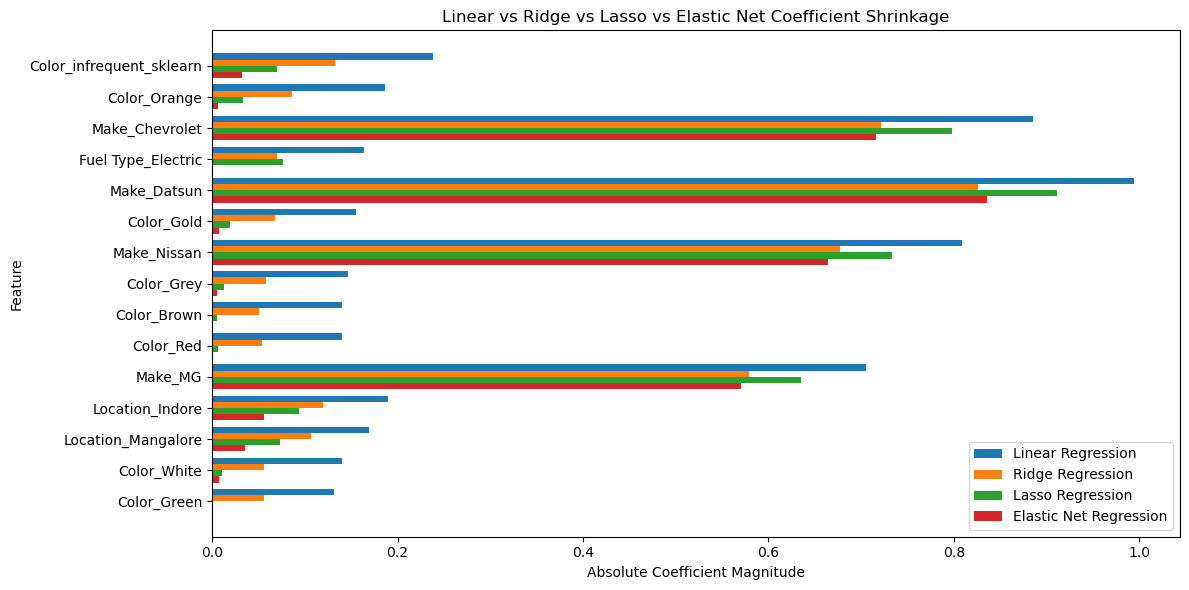

In [27]:
shrinkage_plot_data = (
    elastic_net_shrinkage_summary
    .head(15)
    .copy()
)

y_positions = np.arange(
    len(shrinkage_plot_data)
)

bar_width = 0.20

plt.figure(figsize=(12, 6))

plt.barh(
    y_positions - 0.30,
    shrinkage_plot_data["Linear Coefficient"].abs(),
    height=bar_width,
    label="Linear Regression"
)

plt.barh(
    y_positions - 0.10,
    shrinkage_plot_data["Ridge Coefficient"].abs(),
    height=bar_width,
    label="Ridge Regression"
)

plt.barh(
    y_positions + 0.10,
    shrinkage_plot_data["Lasso Coefficient"].abs(),
    height=bar_width,
    label="Lasso Regression"
)

plt.barh(
    y_positions + 0.30,
    shrinkage_plot_data["Elastic Net Coefficient"].abs(),
    height=bar_width,
    label="Elastic Net Regression"
)

plt.yticks(
    y_positions,
    shrinkage_plot_data["Feature"]
)

plt.gca().invert_yaxis()

plt.title(
    "Linear vs Ridge vs Lasso vs Elastic Net Coefficient Shrinkage"
)
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()

plt.savefig(
    figure_directory / "elastic_net_coefficient_shrinkage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The visualization confirms that all regularized models reduced coefficient magnitudes compared with Linear Regression for the selected features.

Elastic Net applied particularly strong shrinkage to color and location categories. It reduced some coefficients, such as `Fuel Type_Electric`, `Color_Brown`, and `Color_Green`, to exactly zero.

For major vehicle-make features, Elastic Net retained substantial coefficients but generally reduced their magnitudes compared with Linear and Lasso. The plot displays absolute magnitudes only, so coefficient direction must be checked from the coefficient table.

## 13. Analyze Elastic Net Coefficient Stability Across Folds

Coefficient stability will be examined across the same five training folds.

The standard deviation of each coefficient across folds will later be used as the stability measure. A smaller standard deviation indicates that the coefficient changes less when the training sample changes.

To maintain the same 160-column feature space, the preprocessing fitted on the training data will be used for this descriptive analysis. The test set will not be used, and this analysis will not influence hyperparameter selection.

In [28]:
processed_X_train = (
    best_elastic_net_model
    .named_steps["preprocessor"]
    .transform(X_train_fe)
)

y_train_log_array = np.asarray(y_train_log)

elastic_net_fold_coefficients = []

for fold_train_indices, _ in cv_strategy.split(processed_X_train):
    fold_elastic_net = ElasticNet(
        alpha=best_elastic_net_alpha,
        l1_ratio=best_elastic_net_l1_ratio,
        max_iter=50000
    )

    fold_elastic_net.fit(
        processed_X_train[fold_train_indices],
        y_train_log_array[fold_train_indices]
    )

    elastic_net_fold_coefficients.append(
        fold_elastic_net.coef_
    )

elastic_net_coefficient_matrix = np.array(
    elastic_net_fold_coefficients
)

print(
    "Processed training shape:",
    processed_X_train.shape
)
print(
    "Elastic Net coefficient matrix:",
    elastic_net_coefficient_matrix.shape
)

Processed training shape: (1647, 160)
Elastic Net coefficient matrix: (5, 160)


#### Observation

The processed training data contains 1,647 observations and 160 features.

The Elastic Net coefficient matrix has the expected shape of `5 × 160`. Each row represents coefficients learned from one training fold, while each column represents the same processed feature.

This matrix can now be used to measure coefficient variability and feature-selection consistency across folds.

### 13.1 Compare Coefficient Stability and Selection Consistency

The standard deviation of every Elastic Net coefficient will be calculated across the five folds.

Elastic Net feature-selection consistency will also be measured by counting how many folds retained each feature. A feature selected in all five folds is more consistently retained than a feature selected in only one or two folds.

The results will be combined with the saved Linear, Ridge, and Lasso stability results.

In [29]:
previous_coefficient_stability = pd.read_csv(
    results_directory / "lasso_coefficient_stability.csv"
)

elastic_net_coefficient_sd = (
    elastic_net_coefficient_matrix.std(axis=0)
)

elastic_net_folds_selected = (
    elastic_net_coefficient_matrix != 0
).sum(axis=0)

elastic_net_stability = pd.DataFrame({
    "Feature": elastic_net_feature_names,
    "Elastic Net Coefficient SD": elastic_net_coefficient_sd,
    "Elastic Net Folds Selected": elastic_net_folds_selected
})

elastic_net_stability[
    "Elastic Net Selection Frequency (%)"
] = (
    elastic_net_stability["Elastic Net Folds Selected"]
    / 5
    * 100
)

all_model_stability = (
    previous_coefficient_stability.merge(
        elastic_net_stability,
        on="Feature",
        how="inner",
        validate="one_to_one"
    )
)

all_model_stability[
    "Elastic Net Stability Improvement from Linear"
] = (
    all_model_stability["Linear Coefficient SD"]
    - all_model_stability["Elastic Net Coefficient SD"]
)

elastic_net_more_stable_than_linear = (
    all_model_stability["Elastic Net Coefficient SD"]
    <
    all_model_stability["Linear Coefficient SD"]
).sum()

elastic_net_more_stable_than_ridge = (
    all_model_stability["Elastic Net Coefficient SD"]
    <
    all_model_stability["Ridge Coefficient SD"]
).sum()

elastic_net_more_stable_than_lasso = (
    all_model_stability["Elastic Net Coefficient SD"]
    <
    all_model_stability["Lasso Coefficient SD"]
).sum()

elastic_net_selected_all_folds = (
    all_model_stability["Elastic Net Folds Selected"] == 5
).sum()

elastic_net_selected_some_folds = (
    (
        all_model_stability["Elastic Net Folds Selected"] > 0
    )
    &
    (
        all_model_stability["Elastic Net Folds Selected"] < 5
    )
).sum()

elastic_net_selected_no_folds = (
    all_model_stability["Elastic Net Folds Selected"] == 0
).sum()

print(
    "Matched features:",
    len(all_model_stability)
)

print()
print(
    "Mean coefficient SD — Linear:",
    round(all_model_stability["Linear Coefficient SD"].mean(), 4)
)
print(
    "Mean coefficient SD — Ridge:",
    round(all_model_stability["Ridge Coefficient SD"].mean(), 4)
)
print(
    "Mean coefficient SD — Lasso:",
    round(all_model_stability["Lasso Coefficient SD"].mean(), 4)
)
print(
    "Mean coefficient SD — Elastic Net:",
    round(all_model_stability["Elastic Net Coefficient SD"].mean(), 4)
)

print()
print(
    "Median coefficient SD — Linear:",
    round(all_model_stability["Linear Coefficient SD"].median(), 4)
)
print(
    "Median coefficient SD — Ridge:",
    round(all_model_stability["Ridge Coefficient SD"].median(), 4)
)
print(
    "Median coefficient SD — Lasso:",
    round(all_model_stability["Lasso Coefficient SD"].median(), 4)
)
print(
    "Median coefficient SD — Elastic Net:",
    round(all_model_stability["Elastic Net Coefficient SD"].median(), 4)
)

print()
print(
    "Elastic Net more stable than Linear:",
    elastic_net_more_stable_than_linear
)
print(
    "Elastic Net more stable than Ridge:",
    elastic_net_more_stable_than_ridge
)
print(
    "Elastic Net more stable than Lasso:",
    elastic_net_more_stable_than_lasso
)

print()
print(
    "Selected in all 5 folds:",
    elastic_net_selected_all_folds
)
print(
    "Selected in some folds:",
    elastic_net_selected_some_folds
)
print(
    "Selected in no folds:",
    elastic_net_selected_no_folds
)

elastic_net_stability_summary = (
    all_model_stability.sort_values(
        "Elastic Net Stability Improvement from Linear",
        ascending=False
    )
)

elastic_net_stability_summary[[
    "Feature",
    "Linear Coefficient SD",
    "Ridge Coefficient SD",
    "Lasso Coefficient SD",
    "Elastic Net Coefficient SD",
    "Elastic Net Folds Selected",
    "Elastic Net Selection Frequency (%)"
]].head(15).round(4)

Matched features: 160

Mean coefficient SD — Linear: 0.0518
Mean coefficient SD — Ridge: 0.0323
Mean coefficient SD — Lasso: 0.0299
Mean coefficient SD — Elastic Net: 0.0238

Median coefficient SD — Linear: 0.0464
Median coefficient SD — Ridge: 0.0253
Median coefficient SD — Lasso: 0.0238
Median coefficient SD — Elastic Net: 0.0166

Elastic Net more stable than Linear: 143
Elastic Net more stable than Ridge: 127
Elastic Net more stable than Lasso: 144

Selected in all 5 folds: 81
Selected in some folds: 69
Selected in no folds: 10


,Feature,Linear Coefficient SD,Ridge Coefficient SD,Lasso Coefficient SD,Elastic Net Coefficient SD,Elastic Net Folds Selected,Elastic Net Selection Frequency (%)
149,Color_Yellow,0.2053,0.1387,0.1211,0.0755,4,80.0
80,Model_V40 D3 R-Design,0.1381,0.0608,0.0417,0.0090,1,20.0
72,Model_Kwid RXT [2015-2019],0.1063,0.0451,0.0230,0.0020,1,20.0
83,Model_Vitara Brezza VDi (O) [2016-2018],0.1019,0.0329,0.0069,0.0000,0,0.0
67,Model_GLE 300d 4MATIC LWB,0.0945,0.0335,0.0062,0.0000,0,0.0
85,Model_Wagon R LXI CNG (O),0.0936,0.0421,0.0239,0.0028,2,40.0
93,Fuel Type_Electric,0.1364,0.1137,0.0939,0.0475,3,60.0
87,Model_Wagon R VXI,0.0857,0.0225,0.0011,0.0000,0,0.0
56,Model_City V,0.0830,0.0200,0.0061,0.0000,0,0.0
79,Model_Swift VXi [2014-2017],0.0822,0.0232,0.0164,0.0020,1,20.0


#### Observation

Elastic Net achieved the lowest mean coefficient standard deviation of 0.0238 and the lowest median of 0.0166 among the four models.

Its coefficients were more stable than Linear Regression for 143 features, Ridge for 127 features, and Lasso for 144 features. This indicates strong control over coefficient variability under the selected penalty.

However, coefficient stability and feature-selection consistency are different concepts. Only 81 features were selected in all five folds, while 69 were selected in some folds. Therefore, several weak features moved between zero and non-zero status when the training sample changed.

Strong shrinkage can reduce coefficient standard deviation even when the selection status of some features is not fully stable.

## 14. Examine Elastic Net Under Multicollinearity

The previously calculated VIF values will be combined with Elastic Net coefficients for the 12 numerical features.

VIF measures multicollinearity in the feature data. Elastic Net does not reduce the VIF values themselves. Instead, its combined penalty can reduce coefficient magnitude, improve stability, and select among correlated predictors.

The L1 component supports feature selection, while the small L2 component can help stabilize correlated features.

In [30]:
previous_vif_comparison = pd.read_csv(
    results_directory / "lasso_vif_coefficient_comparison.csv"
)

previous_vif_comparison = (
    previous_vif_comparison.rename(
        columns={"Selected": "Lasso Selected"}
    )
)

elastic_net_vif_features = elastic_net_coefficient_table[[
    "Feature",
    "Elastic Net Coefficient",
    "Selected"
]].rename(
    columns={"Selected": "Elastic Net Selected"}
)

elastic_net_vif_comparison = (
    previous_vif_comparison.merge(
        elastic_net_vif_features,
        on="Feature",
        how="inner",
        validate="one_to_one"
    )
)

elastic_net_vif_comparison = (
    elastic_net_vif_comparison.sort_values(
        "VIF",
        ascending=False
    ).reset_index(drop=True)
)

print(
    "VIF features:",
    len(previous_vif_comparison)
)
print(
    "Matched numerical features:",
    len(elastic_net_vif_comparison)
)

elastic_net_vif_comparison.round(4)

VIF features: 12
Matched numerical features: 12


,Feature,VIF,Linear Coefficient,Ridge Coefficient,Absolute Linear Coefficient,Absolute Ridge Coefficient,Magnitude Change,Lasso Coefficient,Absolute Lasso Coefficient,Lasso Selected,Elastic Net Coefficient,Elastic Net Selected
0,Power_BHP,18.5668,0.3299,0.3277,0.3299,0.3277,0.0022,0.3274,0.3274,True,0.3238,True
1,Torque_NM,17.8130,-0.1413,-0.1285,0.1413,0.1285,0.0128,-0.1270,0.1270,True,-0.1114,True
2,Engine_CC,8.7009,0.0248,0.0207,0.0248,0.0207,0.0041,0.0184,0.0184,True,0.0142,True
3,Power_RPM,7.8623,0.0018,0.0050,0.0018,0.0050,-0.0032,0.0006,0.0006,True,0.0000,False
4,Length,5.8289,0.2246,0.2205,0.2246,0.2205,0.0041,0.2218,0.2218,True,0.2169,True
5,Torque_RPM_Clean,4.5594,-0.0489,-0.0539,0.0489,0.0539,-0.0051,-0.0490,0.0490,True,-0.0501,True
6,Fuel Tank Capacity,4.5303,0.0109,0.0198,0.0109,0.0198,-0.0089,0.0172,0.0172,True,0.0233,True
7,Width,4.2695,0.0202,0.0226,0.0202,0.0226,-0.0024,0.0212,0.0212,True,0.0222,True
8,Height,2.9507,0.0975,0.0825,0.0975,0.0825,0.0151,0.0898,0.0898,True,0.0824,True
9,Seating Capacity,2.7245,-0.0456,-0.0425,0.0456,0.0425,0.0032,-0.0438,0.0438,True,-0.0421,True


#### Observation

Substantial multicollinearity remains among the technical features, especially `Power_BHP`, `Torque_NM`, `Engine_CC`, and `Power_RPM`.

Elastic Net retained `Power_BHP`, `Torque_NM`, and `Engine_CC` but reduced their coefficient magnitudes compared with Linear Regression. It set the `Power_RPM` coefficient exactly to zero, suggesting that its information was sufficiently represented by other correlated technical features.

Some coefficients increased slightly because regularization can redistribute predictive influence among correlated variables. Therefore, Elastic Net does not guarantee that every individual coefficient will become smaller.

Elastic Net did not remove multicollinearity from the data, but it controlled its effect through shrinkage, feature selection, and improved coefficient stability.

## 15. Visualize Actual vs Predicted Prices

Actual test prices will be compared with Elastic Net predictions.

The red diagonal line represents perfect predictions. Points close to this line indicate accurate predictions, while larger distances indicate greater prediction error.

Both axes will use logarithmic scaling so that low-price and high-price vehicles can be examined clearly in the same plot.

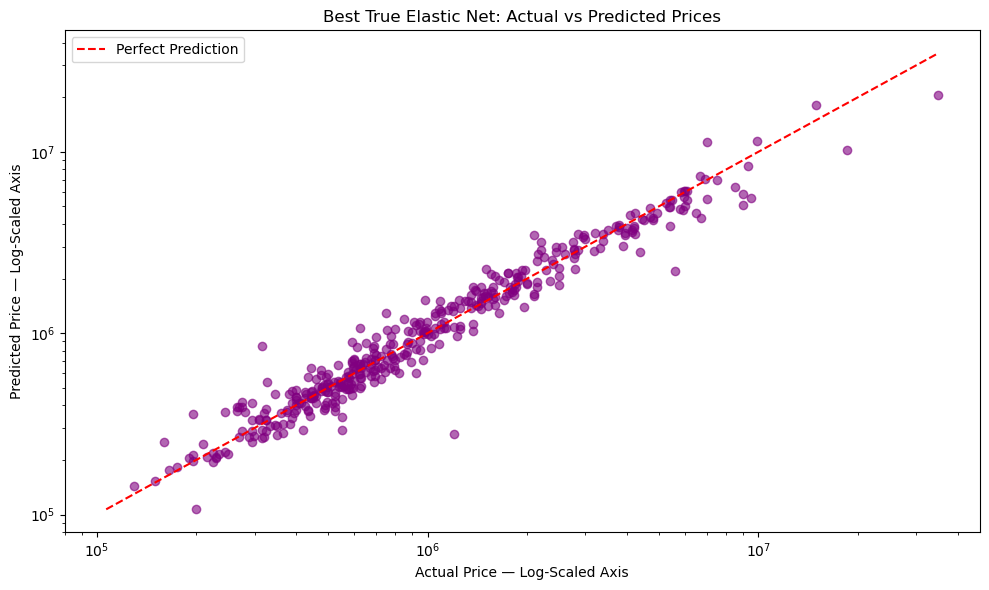

In [32]:
minimum_plot_price = min(
    y_test.min(),
    best_elastic_net_predictions.min()
)

maximum_plot_price = max(
    y_test.max(),
    best_elastic_net_predictions.max()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    best_elastic_net_predictions,
    alpha=0.60,
    color="purple"
)

plt.plot(
    [minimum_plot_price, maximum_plot_price],
    [minimum_plot_price, maximum_plot_price],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Best True Elastic Net: Actual vs Predicted Prices"
)
plt.xlabel("Actual Price — Log-Scaled Axis")
plt.ylabel("Predicted Price — Log-Scaled Axis")
plt.legend()
plt.tight_layout()

plt.savefig(
    figure_directory / "elastic_net_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

Most observations lie close to the perfect-prediction line, indicating strong agreement between actual and predicted prices across the main price range.

Prediction dispersion increases for expensive vehicles, and several high-price cars lie below the reference line. This indicates underprediction of some luxury vehicles.

The model captures the overall pricing pattern well, but extreme and rare vehicles remain more difficult to predict. This visual pattern is consistent with the strong R² and the relatively high RMSE.

## 16. Analyze Elastic Net Residuals

Residuals will be calculated as:

`Residual = Actual Price − Predicted Price`

A positive residual indicates underprediction, while a negative residual indicates overprediction.

Residuals will be examined on both the original Price scale and the Log Price scale. The log scale is especially important because Elastic Net was trained using the log-transformed target.

In [33]:
y_test_array = np.asarray(y_test)

elastic_net_original_residuals = (
    y_test_array
    - best_elastic_net_predictions
)

elastic_net_log_residuals = (
    np.log1p(y_test_array)
    - best_elastic_net_predictions_log
)

print("Original Price Residuals")
print(
    "Mean:",
    round(elastic_net_original_residuals.mean(), 2)
)
print(
    "Median:",
    round(np.median(elastic_net_original_residuals), 2)
)
print(
    "Standard deviation:",
    round(elastic_net_original_residuals.std(), 2)
)
print(
    "Positive residuals:",
    np.sum(elastic_net_original_residuals > 0)
)
print(
    "Negative residuals:",
    np.sum(elastic_net_original_residuals < 0)
)

print()
print("Log-Scale Residuals")
print(
    "Mean:",
    round(elastic_net_log_residuals.mean(), 4)
)
print(
    "Median:",
    round(np.median(elastic_net_log_residuals), 4)
)
print(
    "Standard deviation:",
    round(elastic_net_log_residuals.std(), 4)
)

Original Price Residuals
Mean: 88870.13
Median: -2012.75
Standard deviation: 994447.99
Positive residuals: 200
Negative residuals: 212

Log-Scale Residuals
Mean: 0.0022
Median: -0.0038
Standard deviation: 0.2124


#### Observation

The original-scale residual median is close to zero, and positive and negative residual counts are reasonably balanced. This indicates no strong systematic prediction direction for most observations.

The positive mean residual of approximately 88,870 is much larger than the median because a small number of expensive vehicles have large positive residuals. These underpredictions pull the mean upward.

On the training target scale, the residual mean of 0.0022 and median of -0.0038 are both close to zero. This indicates that Elastic Net predictions are well-centered on the Log Price scale.

### 16.1 Plot Residuals Against Predicted Values

Residuals will be plotted against predicted values on both the original and log target scales.

A well-behaved residual plot should show points distributed around the zero line without a strong systematic pattern. Increasing spread, curved structure, or isolated points can indicate heteroscedasticity, model limitations, or unusual observations.

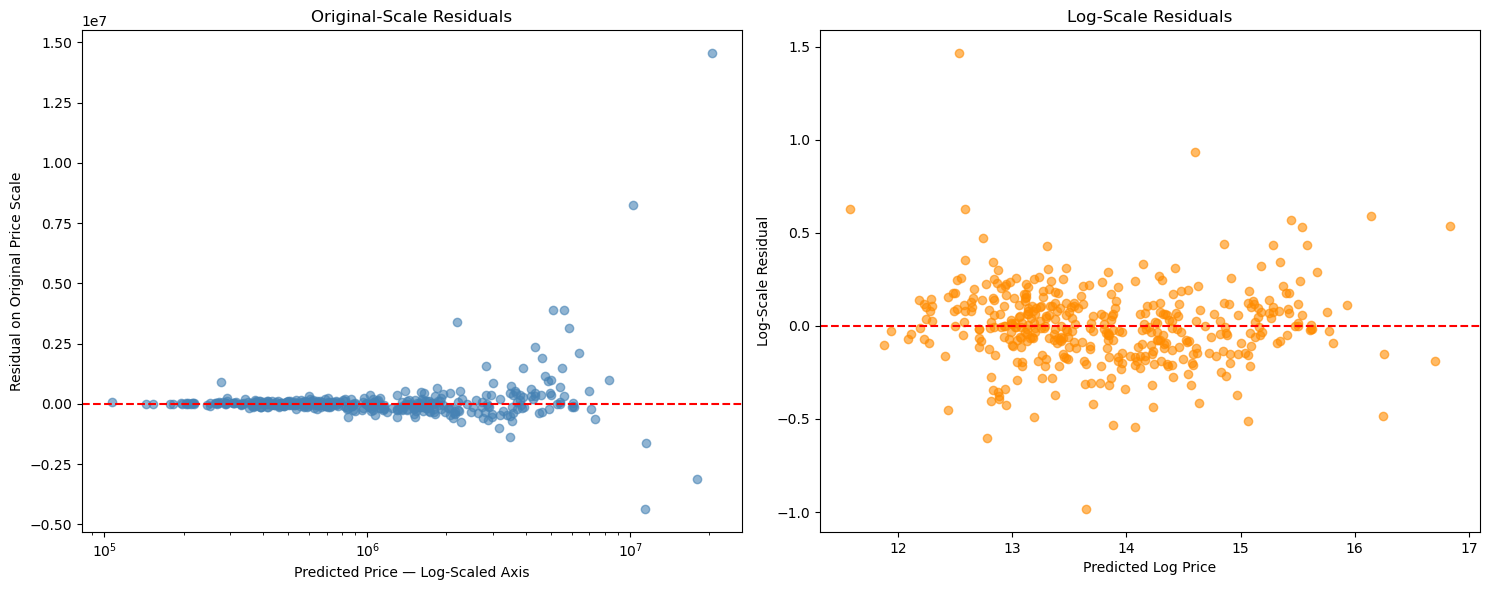

In [34]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

axes[0].scatter(
    best_elastic_net_predictions,
    elastic_net_original_residuals,
    alpha=0.60,
    color="steelblue"
)

axes[0].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_xscale("log")
axes[0].set_title("Original-Scale Residuals")
axes[0].set_xlabel("Predicted Price — Log-Scaled Axis")
axes[0].set_ylabel("Residual on Original Price Scale")

axes[1].scatter(
    best_elastic_net_predictions_log,
    elastic_net_log_residuals,
    alpha=0.60,
    color="darkorange"
)

axes[1].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[1].set_title("Log-Scale Residuals")
axes[1].set_xlabel("Predicted Log Price")
axes[1].set_ylabel("Log-Scale Residual")

plt.tight_layout()

plt.savefig(
    figure_directory / "elastic_net_residuals_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The original-scale residual plot shows increasing error spread as predicted prices increase. This indicates heteroscedasticity, because errors measured in rupees are much larger for expensive vehicles.

The log-scale residuals are more evenly distributed around zero, confirming that the log transformation reduced the unequal error variance substantially.

A weak curved pattern and several extreme residuals remain on the log scale. This suggests that some non-linear relationships, rare vehicles, or unobserved factors are not fully captured by the linear Elastic Net model.

### 16.2 Examine Log-Scale Residual Distribution and Normality

A histogram with a density curve will show the shape and center of the log-scale residual distribution.

A Q-Q plot will compare the residual quantiles with theoretical normal-distribution quantiles. Points close to the reference line indicate approximate normality, while deviations at the ends indicate heavy tails or outliers.

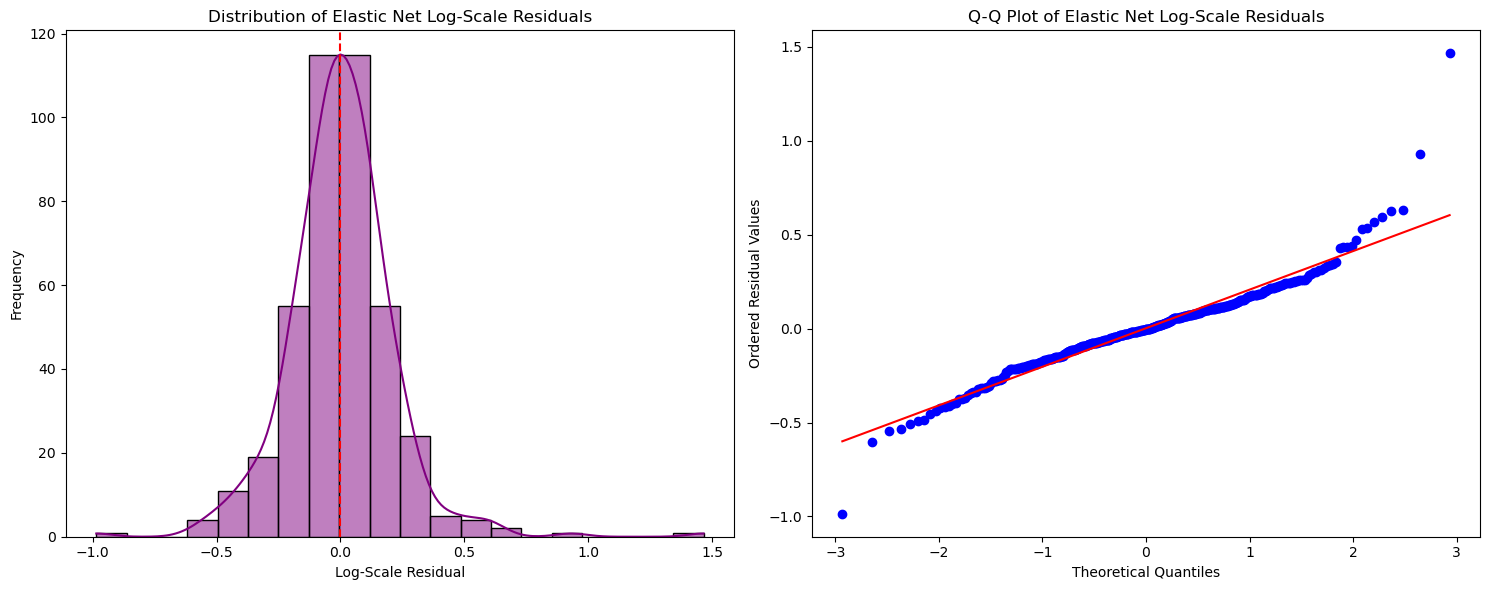

In [35]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.histplot(
    elastic_net_log_residuals,
    bins=20,
    kde=True,
    color="purple",
    ax=axes[0]
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_title(
    "Distribution of Elastic Net Log-Scale Residuals"
)
axes[0].set_xlabel("Log-Scale Residual")
axes[0].set_ylabel("Frequency")

stats.probplot(
    elastic_net_log_residuals,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of Elastic Net Log-Scale Residuals"
)
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Ordered Residual Values")

plt.tight_layout()

plt.savefig(
    figure_directory / "elastic_net_log_residual_diagnostics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The log-scale residual distribution is centered close to zero and is approximately bell-shaped in its central region.

Most Q-Q plot points follow the reference line near the center. However, both tails deviate from the line, with stronger deviation in the upper tail. This indicates heavy tails and several unusual prediction errors.

Therefore, residual normality is only approximate. The model performs well for most observations, but rare vehicles and extreme errors remain important limitations.

## 17. Inspect the Largest Elastic Net Prediction Errors

The ten test observations with the largest absolute errors will be identified.

This analysis will show which vehicles are most difficult for the model to predict and whether the largest errors are underpredictions or overpredictions.

These observations will be examined as model limitations. They will not be removed simply because their prediction errors are large.

In [36]:
elastic_net_error_analysis = X_test[[
    "Make",
    "Model",
    "Year",
    "Kilometer",
    "Location"
]].copy()

elastic_net_error_analysis["Actual Price"] = y_test

elastic_net_error_analysis["Predicted Price"] = (
    best_elastic_net_predictions
)

elastic_net_error_analysis["Residual"] = (
    elastic_net_original_residuals
)

elastic_net_error_analysis["Absolute Error"] = (
    elastic_net_error_analysis["Residual"].abs()
)

elastic_net_error_analysis["Percentage Error"] = (
    elastic_net_error_analysis["Absolute Error"]
    / elastic_net_error_analysis["Actual Price"]
    * 100
)

elastic_net_error_analysis["Error Direction"] = np.where(
    elastic_net_error_analysis["Residual"] > 0,
    "Underprediction",
    "Overprediction"
)

elastic_net_largest_errors = (
    elastic_net_error_analysis.sort_values(
        "Absolute Error",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

elastic_net_largest_errors.round({
    "Actual Price": 2,
    "Predicted Price": 2,
    "Residual": 2,
    "Absolute Error": 2,
    "Percentage Error": 2
})

,Make,Model,Year,Kilometer,Location,Actual Price,Predicted Price,Residual,Absolute Error,Percentage Error,Error Direction
0,Ferrari,488 GTB,2018,9500,Delhi,35000000,20444373.80,14555626.20,14555626.20,41.59,Underprediction
1,Mercedes-Benz,S-Class S 350D [2018-2020],2021,5000,Pune,18500000,10236575.05,8263424.95,8263424.95,44.67,Underprediction
2,Mercedes-Benz,C-Coupe 43 AMG 4MATIC,2020,19000,Chennai,7000000,11376179.30,-4376179.30,4376179.30,62.52,Overprediction
3,Porsche,718 Cayman [2017-2020],2017,7000,Faridabad,9000000,5094970.76,3905029.24,3905029.24,43.39,Underprediction
4,Porsche,718 Boxster,2018,20000,Delhi,9500000,5598047.64,3901952.36,3901952.36,41.07,Underprediction
5,Porsche,Panamera 3.0 Diesel,2015,33000,Delhi,5590000,2201347.60,3388652.40,3388652.40,60.62,Underprediction
6,Maserati,Levante Diesel,2017,40000,Chennai,9000000,5834376.71,3165623.29,3165623.29,35.17,Underprediction
7,Porsche,Cayenne Base,2021,7534,Mumbai,14900000,18010967.01,-3110967.01,3110967.01,20.88,Overprediction
8,Audi,Q7 45 TDI Technology Pack,2018,39850,Surat,6700000,4331357.82,2368642.18,2368642.18,35.35,Underprediction
9,Volvo,XC90 D5 Inscription,2021,32500,Ahmedabad,8500000,6377730.14,2122269.86,2122269.86,24.97,Underprediction


#### Observation

The largest prediction errors are concentrated among rare luxury vehicles from Ferrari, Mercedes-Benz, Porsche, Maserati, Audi, and Volvo.

Eight of the ten largest errors are underpredictions. The Ferrari 488 GTB produced the largest absolute error of approximately 14.56 million, while several other luxury vehicles had percentage errors above 40%.

These observations explain the positive mean residual and the high RMSE. The model tends to pull rare and extremely expensive vehicles toward the more common price range.

Limited luxury-vehicle examples, rare categories, high-cardinality models, and missing market-specific information may contribute to these errors.

## 18. Research Interpretation

Cross-validation selected `alpha = 0.0002` and placed the optimum at the pure-Lasso endpoint. The best true Elastic Net combination used `l1_ratio = 0.99`, and its validation Log RMSE differed from the endpoint by only 0.000012. This indicates that the dataset strongly favors L1 regularization, while a small L2 contribution can be retained with negligible validation loss.

The Best True Elastic Net achieved the lowest test MAE of approximately 297,854, although Basic Ridge retained the best RMSE and R². The small performance differences among the strongest models suggest that regularization mainly changed coefficient structure rather than producing a large predictive improvement.

Elastic Net reduced the coefficient L2 norm by 18.76% compared with Linear Regression, removed 36 processed features, and produced the lowest mean coefficient standard deviation of 0.0238. These findings provide evidence of stronger shrinkage, sparsity, and coefficient stability.

However, the comparison is based on one dataset and one fixed test split. The results should be interpreted as dataset-specific evidence rather than proof that Elastic Net is universally superior.

## 19. Industry Interpretation

The Best True Elastic Net model provides strong average prediction accuracy and produces no negative price predictions. Its complete preprocessing and modelling pipeline can also handle missing values, rare categories, and unseen test categories without failing.

The model is most suitable as a pricing-support tool for common used-car segments. It could provide an initial estimated price for dealerships, online marketplaces, or valuation teams.

The high RMSE and largest-error analysis show that rare luxury vehicles require additional caution. Predictions for such vehicles should be flagged for expert review instead of being used as automatic final valuations.

Although Elastic Net created a sparse prediction equation, the complete raw input pipeline should still be preserved. Model performance and category distributions should be monitored, and the model should be retrained when market prices or vehicle patterns change.

## 20. Limitations

- The dataset contains only 2,059 observations. Rare luxury brands and models have limited representation, which reduces prediction reliability for extreme-price vehicles.

- The dataset may not include important pricing factors such as accident history, service history, detailed vehicle condition, market demand, and transaction date.

- High-cardinality categories required rare-category grouping. Unseen categories were encoded as all zeros, which prevents pipeline failure but provides limited information for those observations.

- Substantial multicollinearity remains in the feature data. Elastic Net controls its coefficient effects but does not remove the underlying correlations.

- Elastic Net is a linear additive model. Remaining residual patterns suggest that some non-linear relationships and feature interactions are not fully captured.

- Log predictions were converted back using `expm1` without a retransformation-bias correction. This may contribute to underprediction on the original Price scale, especially for expensive vehicles.

- Hyperparameters were selected using training cross-validation, but final performance was measured on one fixed test split. External validation and repeated evaluation would provide stronger evidence of generalization.

- The coefficient-stability analysis used a fixed training-derived feature space and should be interpreted as descriptive evidence rather than an independent performance estimate.

## 21. Final Conclusion

The final true Elastic Net model used `alpha = 0.0002` and `l1_ratio = 0.99`. Its test results were:

- MAE: approximately 297,854
- RMSE: approximately 998,411
- R²: 0.8573
- Negative predictions: 0

Elastic Net achieved the lowest MAE among the compared models and outperformed the Best Lasso in all three evaluation metrics. Basic Ridge retained the lowest RMSE and highest R², showing that no single model was best under every evaluation criterion.

Beyond prediction performance, Elastic Net produced the strongest overall shrinkage, removed 36 processed features, reduced the coefficient L2 norm by 18.76% compared with Linear Regression, and achieved the lowest mean coefficient standard deviation.

The cross-validation optimum was located at the pure-Lasso endpoint, while the selected true Elastic Net solution performed almost identically with a small L2 contribution. Therefore, this dataset mainly favors L1 regularization.

Overall, Elastic Net provides a strong balance of prediction accuracy, sparsity, and coefficient stability for common used-car price estimation. However, rare luxury vehicles, extreme errors, and remaining non-linear residual patterns require caution and further modelling.

## 22. Save Elastic Net Results

Important cross-validation, evaluation, coefficient, stability, multicollinearity, and error-analysis tables will be saved in the `results/` directory.

The diagnostic figures were already saved in `results/figures/` when their plotting cells were executed. These files support reproducibility and allow the results to be used in the README and final project comparison.

In [37]:
elastic_net_initial_cv_results = pd.DataFrame({
    "Alpha": elastic_net_search.cv_results_[
        "param_elastic_net__alpha"
    ],
    "L1 Ratio": elastic_net_search.cv_results_[
        "param_elastic_net__l1_ratio"
    ],
    "Mean Train Log RMSE": -elastic_net_search.cv_results_[
        "mean_train_score"
    ],
    "Mean Validation Log RMSE": -elastic_net_search.cv_results_[
        "mean_test_score"
    ],
    "Validation RMSE Standard Deviation": elastic_net_search.cv_results_[
        "std_test_score"
    ],
    "Rank": elastic_net_search.cv_results_[
        "rank_test_score"
    ]
})

elastic_net_initial_cv_results["Alpha"] = pd.to_numeric(
    elastic_net_initial_cv_results["Alpha"]
)

elastic_net_initial_cv_results["L1 Ratio"] = pd.to_numeric(
    elastic_net_initial_cv_results["L1 Ratio"]
)

elastic_net_initial_cv_results = (
    elastic_net_initial_cv_results.sort_values(
        ["Rank", "Alpha", "L1 Ratio"]
    ).reset_index(drop=True)
)

elastic_net_initial_cv_results.to_csv(
    results_directory / "elastic_net_initial_cv_results.csv",
    index=False
)

refined_elastic_net_cv_results.sort_values(
    "Rank"
).to_csv(
    results_directory / "elastic_net_refined_cv_results.csv",
    index=False
)

elastic_net_model_comparison.to_csv(
    results_directory / "elastic_net_model_comparison.csv",
    index=False
)

elastic_net_coefficient_table.to_csv(
    results_directory / "elastic_net_regression_coefficients.csv",
    index=False
)

all_model_coefficient_comparison.to_csv(
    results_directory
    / "linear_ridge_lasso_elastic_net_coefficients.csv",
    index=False
)

all_model_stability.to_csv(
    results_directory / "elastic_net_coefficient_stability.csv",
    index=False
)

elastic_net_vif_comparison.to_csv(
    results_directory
    / "elastic_net_vif_coefficient_comparison.csv",
    index=False
)

elastic_net_largest_errors.to_csv(
    results_directory
    / "elastic_net_largest_prediction_errors.csv",
    index=False
)

print("Elastic Net result files saved successfully.")
print()
print("1. elastic_net_initial_cv_results.csv")
print("2. elastic_net_refined_cv_results.csv")
print("3. elastic_net_model_comparison.csv")
print("4. elastic_net_regression_coefficients.csv")
print("5. linear_ridge_lasso_elastic_net_coefficients.csv")
print("6. elastic_net_coefficient_stability.csv")
print("7. elastic_net_vif_coefficient_comparison.csv")
print("8. elastic_net_largest_prediction_errors.csv")

Elastic Net result files saved successfully.

1. elastic_net_initial_cv_results.csv
2. elastic_net_refined_cv_results.csv
3. elastic_net_model_comparison.csv
4. elastic_net_regression_coefficients.csv
5. linear_ridge_lasso_elastic_net_coefficients.csv
6. elastic_net_coefficient_stability.csv
7. elastic_net_vif_coefficient_comparison.csv
8. elastic_net_largest_prediction_errors.csv
